### Average Precision Estimation DENTEX DATA ###

In [1]:
import sys
import os
import numpy as np
import json
import copy
import glob
import pandas as pd
import logging
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from sklearn import metrics as skmetrics
import seaborn as sns

logger = logging.getLogger(__name__)

# PyTorch
import torch
from torchvision import ops

%load_ext autoreload
%autoreload 2
import computervision
from computervision.imageproc import is_image, ImageData, clipxywh, xyxy2xywh, xywh2xyxy, plot_boxes
from computervision.datasets import DETRdataset
from computervision.transformations import AugmentationTransform
from computervision.performance import DetectionMetrics
from computervision.inference import DETRinference, get_gpu_info

print(f'Project version: {computervision.__version__}')
print(f'Authors: {computervision.__authors__}')
print(f'Python version:  {sys.version}')

Project version: v0.0.2
Authors: The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.3 (main, Jun 18 2025, 17:59:45) [GCC 13.3.0]


In [2]:
# Check GPU availability
device, device_str = get_gpu_info()

CUDA available: True
Number of GPUs found:  1
Current device ID: 0
GPU device name:   NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version:   2.8.0a0+34c6371d24.nv25.08
CUDA version:      13.0
CUDNN version:     91200
Current device:    cuda:0


### Test data ###

In [3]:
# Dentex test data
data_dir = os.environ.get('DATA')
dataset_name = 'dataset_object_dentex_251011'
image_dir = os.path.join(data_dir, dataset_name, 'test')
test_df_file_name = 'dataset_object_dentex_251011_test.parquet'
test_df_file = os.path.join(image_dir, test_df_file_name)
df = pd.read_parquet(test_df_file)

# Filter the data frame
dset_col = 'dset'
pos_col = 'ada'
file_col = 'file_name'
bbox_col = 'bbox'
df = df.loc[(df[dset_col].isin(['val', 'test'])) & (df['transformation'] == 5)]
display(df.head(2))
print(f'Images in test data: {len(df[file_col].unique())}')
print(f'Annotations:         {df.shape[0]}')

,bbox,quadrant,ada,file_name,file_base_name,quadrants,height,width,transformation,transformation_name,dset
34,"[466, 196, 59, 308]",1,8,val_train_143_01_05.png,train_143,1,640,640,5,test_set,val
35,"[407, 221, 70, 283]",1,7,val_train_143_01_05.png,train_143,1,640,640,5,test_set,val


Images in test data: 285
Annotations:         2287


### Model ###

In [5]:
model_name = 'rtdetr_dtx_251012_08'
model_dir = os.path.join(data_dir, 'model', model_name)

checkpoint_paths = glob.glob(os.path.join(model_dir, 'checkpoint-*'))
checkpoint_numbers = [int(os.path.basename(checkpoint).split('-')[-1]) for checkpoint in checkpoint_paths]
checkpoints = dict(zip(checkpoint_numbers, checkpoint_paths))

# checkpoint_dir = os.path.join(model_dir, f'checkpoint-{checkpoint}')
display(checkpoints)

model_config_file = os.path.join(model_dir, f'{model_name}.json')
with open(model_config_file, mode='r') as file:
    model_config = json.load(file)
display(*list(model_config.keys()), sep='\n')

# Image processor
processor = DETRinference(device_name='cuda:0', 
                          checkpoint_path=checkpoint_paths[0]).processor

{19600: '/app/data_model/model/rtdetr_dtx_251012_08/checkpoint-19600',
 119900: '/app/data_model/model/rtdetr_dtx_251012_08/checkpoint-119900',
 120000: '/app/data_model/model/rtdetr_dtx_251012_08/checkpoint-120000',
 119950: '/app/data_model/model/rtdetr_dtx_251012_08/checkpoint-119950',
 119850: '/app/data_model/model/rtdetr_dtx_251012_08/checkpoint-119850'}

'model_info'

'id2label'

'training_args'

'processor_params'

'bbox_format'

### PyTorch Dataset ###

In [6]:
# Create a PyTorch data set
transforms = AugmentationTransform().get_transforms(name='val')
bbox_format = model_config.get('bbox_format')
dataset = DETRdataset(data=df.copy(), 
                      image_processor=processor, 
                      image_dir=image_dir, 
                      file_name_col=file_col, 
                      label_id_col=None, 
                      bbox_col=None, 
                      bbox_format=bbox_format, 
                      transforms=transforms)
print(f'Total images in test data: {len(dataset)}')

Total images in test data: 285


### Predict bounding boxes on the test data for all checkpoints from this model ###

In [7]:
# Run the forward pass to get the predictions for all checkpoints
threshold = 0.05
pred_raw_list = []
for c, (checkpoint, checkpoint_path) in enumerate(checkpoints.items()):
    print(f'Running checkpoint {checkpoint} {c + 1} / {len(checkpoints)}')
    dtr = DETRinference(device_name='cuda:0', 
                        checkpoint_path=checkpoint_path,
                        batch_size=16)
    pred = dtr.predict_on_dataset(dataset, threshold=threshold)
    pred = pred.assign(checkpoint=checkpoint, pred_threshold=threshold)
    pred_raw_list.append(pred)
    pred_raw = pd.concat(pred_raw_list, axis=0, ignore_index=True).\
                    sort_values(by='checkpoint', ascending=True).\
                    reset_index(drop=True)

Running checkpoint 19600 1 / 5
Predicting batch 10 of 18.
Running checkpoint 119900 2 / 5
Predicting batch 10 of 18.
Running checkpoint 120000 3 / 5
Predicting batch 10 of 18.
Running checkpoint 119950 4 / 5
Predicting batch 10 of 18.
Running checkpoint 119850 5 / 5
Predicting batch 10 of 18.


In [8]:
# Make a copy of the predictions 
pred = copy.deepcopy(pred_raw)

# Add the file names to the data frame
file_names = df[file_col].unique()
id2file = dict(zip(range(len(file_names)), file_names))
pred[file_col] = pred['image_id'].apply(lambda image_id: id2file.get(image_id))

# Add the label names (the positions) to the data frame
id2label = {int(category_id): int(label) for category_id, label in model_config.get('id2label').items()}
pred[pos_col] = pred['category_id'].apply(lambda category_id: id2label.get(category_id))

print(f'Images in output data:     {len(pred['image_id'].unique())}')

# Let's find out if all of the images resulted in predictions
pred_empty = len(pred.loc[pred[pos_col].isnull(), file_col].unique())

# Filter out rows with images that do not have predictions
pred = pred.loc[~pred[pos_col].isnull()]
print(f'Total number of images in data set:             {len(dataset)}')
print(f'Images without predictions for threshold ({threshold}):{pred_empty}')
print(f'Images with predictions:                        {len(pred[file_col].unique())}')

Images in output data:     285
Total number of images in data set:             285
Images without predictions for threshold (0.05):0
Images with predictions:                        285


### Classify predictions: TP, FP, FN ###
We create a method to classify all of the predictions in the data set. 

In [9]:
true_df = copy.deepcopy(df)
pred_df = copy.deepcopy(pred)
bbox_col = 'bbox'
label_col = 'ada'
file_col = 'file_name'
score_col = 'score'
display(pred_df.head(2))

,image_id,image_width,image_height,batch,category_id,bbox,score,area,checkpoint,pred_threshold,file_name,ada
0,0,640,640,0,5,"[324, 148, 88, 356]",0.248717,31328,19600,0.05,val_train_143_01_05.png,6
1,188,640,640,11,29,"[0, 272, 29, 259]",0.078804,7511,19600,0.05,test_train_287_34_05.png,30


In [10]:
pr_df_list = []
ap_df_list = []

iou_list = [0.25, 0.5, 0.7]

for checkpoint in checkpoint_numbers:
    
    pred_df_checkpoint = pred_df.loc[pred_df['checkpoint'] == checkpoint]
    
    # Set up the metrics instance
    metrics = DetectionMetrics(
    true_df=true_df,
    pred_df=pred_df_checkpoint,
    file_col=file_col,
    label_col=label_col,
    bbox_col=bbox_col,
    score_col=score_col)

    for iou_threshold in iou_list:
    
        # Classify the predictions
        classifications, missed = metrics.classify_predictions_df(iou_threshold=iou_threshold)
        pr_df = metrics.ap_from_classifications(classifications=classifications)
        pr_df.insert(loc=0, column='model', value=model_name)
        pr_df.insert(loc=1, column='dataset', value=dataset_name)
        pr_df.insert(loc=2, column='checkpoint', value=checkpoint)
        pr_df.insert(loc=3, column='score_threshold', value=threshold)
        pr_df_list.append(pr_df)
        
        # Get the AUC values
        ap_df = pr_df[[label_col, 'iou_threshold', 'auc', file_col]].\
            groupby([label_col, 'iou_threshold', 'auc']).nunique().\
            reset_index(drop=False).\
            rename(columns={file_col: 'n_predictions'}).\
            sort_values(by=label_col, ascending=True).\
            reset_index(drop=True)
        ap_df.insert(loc=0, column='model', value=model_name)
        ap_df.insert(loc=1, column='dataset', value=dataset_name)
        ap_df.insert(loc=2, column='checkpoint', value=checkpoint)
        ap_df.insert(loc=3, column='score_threshold', value=threshold)
        print(f'mAP for checkpoint {checkpoint} at IoU({iou_threshold}): {ap_df['auc'].mean(): .3f}')
        ap_df_list.append(ap_df)

mAP for checkpoint 19600 at IoU(0.25):  0.516
mAP for checkpoint 19600 at IoU(0.5):  0.666
mAP for checkpoint 19600 at IoU(0.7):  0.570
mAP for checkpoint 119900 at IoU(0.25):  0.844
mAP for checkpoint 119900 at IoU(0.5):  0.820
mAP for checkpoint 119900 at IoU(0.7):  0.650
mAP for checkpoint 120000 at IoU(0.25):  0.833
mAP for checkpoint 120000 at IoU(0.5):  0.822
mAP for checkpoint 120000 at IoU(0.7):  0.661
mAP for checkpoint 119950 at IoU(0.25):  0.834
mAP for checkpoint 119950 at IoU(0.5):  0.815
mAP for checkpoint 119950 at IoU(0.7):  0.649
mAP for checkpoint 119850 at IoU(0.25):  0.837
mAP for checkpoint 119850 at IoU(0.5):  0.818
mAP for checkpoint 119850 at IoU(0.7):  0.654


In [11]:
# Save the output
output_dir = os.path.join(os.environ['DATA'], 'output', model_name)
Path(output_dir).mkdir(parents=True, exist_ok=True)
print(output_dir)
precision_recall_df = pd.concat(pr_df_list, axis=0, ignore_index=True)
average_precision_df = pd.concat(ap_df_list, axis=0, ignore_index=True)

pr_data_name = f'{model_name}_predictions.parquet'
pr_data_file = os.path.join(output_dir, pr_data_name)
precision_recall_df.to_parquet(pr_data_file)
print(f'Saved Precision-Recall data: {pr_data_file}')

ap_data_name = f'{model_name}_ap_per_label.parquet'
ap_data_file = os.path.join(output_dir, ap_data_name)
average_precision_df.to_parquet(ap_data_file)
print(f'Saved Average Precision data: {ap_data_file}')

display(precision_recall_df.head(2))
display(average_precision_df.head(2))

/app/data_model/output/rtdetr_dtx_251012_08
Saved Precision-Recall data: /app/data_model/output/rtdetr_dtx_251012_08/rtdetr_dtx_251012_08_predictions.parquet
Saved Average Precision data: /app/data_model/output/rtdetr_dtx_251012_08/rtdetr_dtx_251012_08_ap_per_label.parquet


,model,dataset,checkpoint,score_threshold,file_name,iou_threshold,score,bbox,ada,TP,IoU,n_missed,duplicate_TP,precision,recall,precision_label,recall_label,auc
0,rtdetr_dtx_251012_08,dataset_object_dentex_251011,19600,0.05,val_train_609_14_05.png,0.25,0.349044,"[74, 90, 138, 179]",1,0,0.858682,0,True,0.0,0.000000,0.250965,2.241379,0.530085
1,rtdetr_dtx_251012_08,dataset_object_dentex_251011,19600,0.05,test_train_226_14_05.png,0.25,0.314252,"[82, 0, 256, 231]",1,1,0.907051,0,False,0.5,0.034483,0.250965,2.241379,0.530085


,model,dataset,checkpoint,score_threshold,ada,iou_threshold,auc,n_predictions
0,rtdetr_dtx_251012_08,dataset_object_dentex_251011,19600,0.05,1,0.25,0.530085,132
1,rtdetr_dtx_251012_08,dataset_object_dentex_251011,19600,0.05,2,0.25,0.266364,117


### Visualizations: bounding boxes ###

In [30]:
checkpoint = 120000
min_score = 0.1
iou_threshold = 0.5
pr_df = precision_recall_df.loc[
    (precision_recall_df['checkpoint'] == checkpoint) & 
    (precision_recall_df['iou_threshold'] == iou_threshold)]

#output_images_dir = os.path.join(output_dir, 'images')
output_images_dir = os.path.join(data_dir, 'output', 'detection', 'ground_truth')
Path(output_images_dir).mkdir(parents=True, exist_ok=True)
print(output_images_dir)

/app/data_model/output/detection/ground_truth


IMAGE 1 / 285


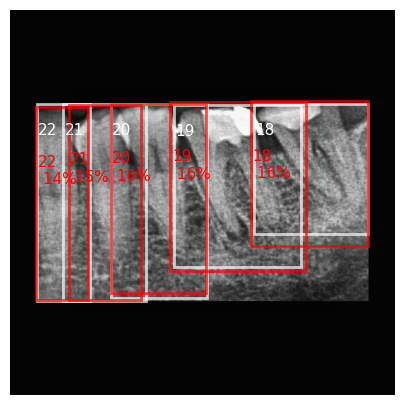

IMAGE 2 / 285


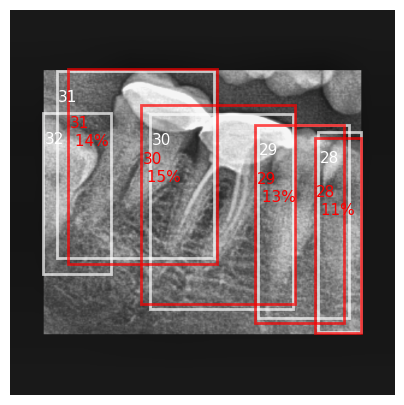

IMAGE 3 / 285


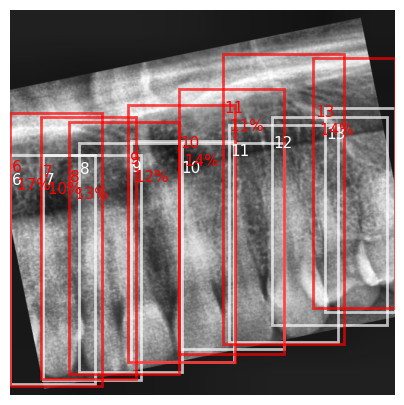

In [36]:
file_list = sorted(list(pr_df[file_col].unique()))
for f, file_name in enumerate(file_list[2:5]):

    print(f'IMAGE {f + 1} / {len(file_list)}')
    
    file = os.path.join(image_dir, file_name)
    im = ImageData().load_image(file)
    im = ImageData().np2color(im)
    im = ImageData().hist_eq(im)
    
    # Create a file name to save the image
    im_file_name = f'{model_name}_{os.path.splitext(file_name)[0]}.png'
    im_file = os.path.join(output_images_dir, im_file_name)
    
    pr_file = pr_df.loc[(pr_df[file_col] == file_name) & (pr_df[score_col] >= min_score)]
    # Take the prediction with the higher score if there is more than one
    pr_file = pr_file.sort_values(by=[label_col, score_col], ascending=False).\
        groupby(label_col).first().\
        reset_index(drop=False)
    
    pr_bbox_list = pr_file[bbox_col].tolist()
    pr_pos_list = pr_file[label_col].tolist()
    pr_score_list = pr_file[score_col].tolist()
    pr_label_list = [f'{pos}\n{score*100: .0f}%' for pos, score in zip(pr_pos_list, pr_score_list)]
    
    df_file = df.loc[df[file_col] == file_name]
    df_bbox_list = df_file[bbox_col].tolist()
    df_pos_list = df_file[label_col].tolist()
    
    fig, ax = plt.subplots(figsize=(5, 5))
    
    ax = plot_boxes(image=im, 
                    box_list=df_bbox_list, 
                    label_list=df_pos_list, 
                    ax=ax, 
                    color='w', 
                    linewidth=2.0, 
                    fontsize=11)
    
    ax = plot_boxes(image=im, 
                    box_list=pr_bbox_list, 
                    label_list=pr_label_list, 
                    ax=ax,
                    color='r',
                    offset_xy=(0, 150), 
                    linewidth=2.0, 
                    fontsize=11)
    
    plt.savefig(im_file, bbox_inches='tight')
    plt.show()

### Visualizations: PR Curves ###

In [37]:
checkpoint = 120000
min_score = 0.1
iou_threshold = 0.5
pr_df = precision_recall_df.loc[precision_recall_df['checkpoint'] == checkpoint]
iou_list = sorted(list(pr_df['iou_threshold'].unique()))
print(iou_list)

plt.style.use('seaborn-v0_8')
cmap = plt.cm.Blues
num_colors = len(iou_list) + 1
colors = [cmap(i) for i in np.linspace(0.6, 1, num_colors)]

output_pr_dir = os.path.join(data_dir, 'output', 'detection', 'PR')
Path(output_pr_dir).mkdir(parents=True, exist_ok=True)

[0.25, 0.5, 0.7]


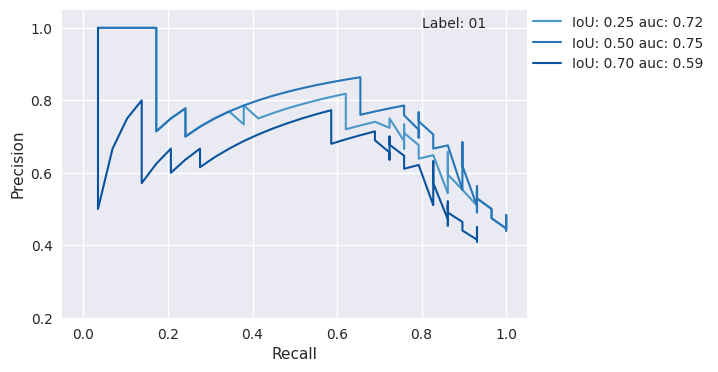

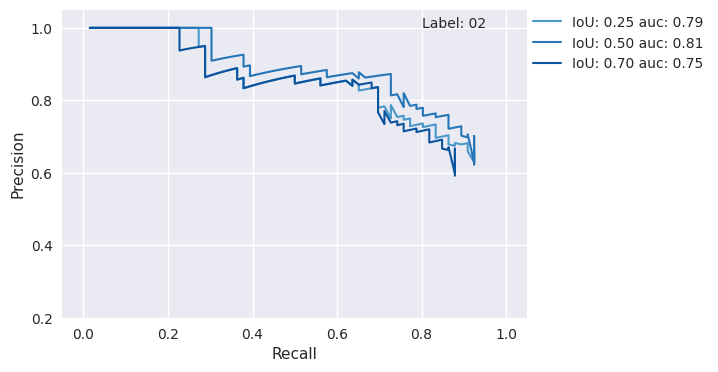

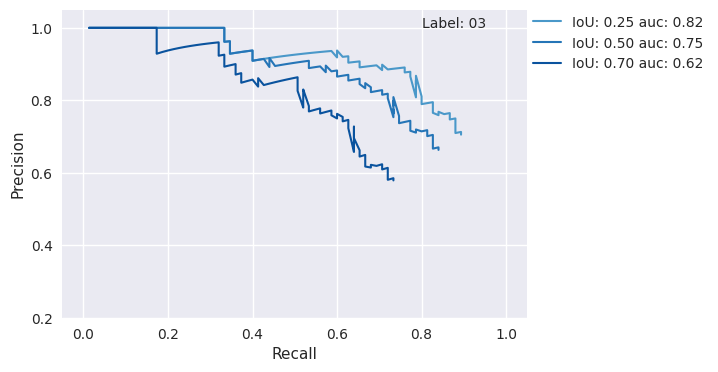

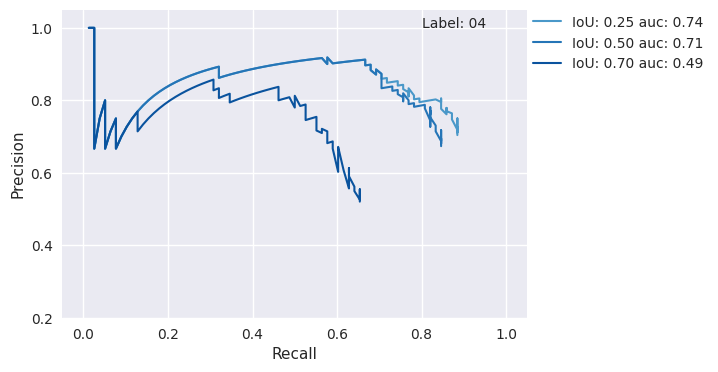

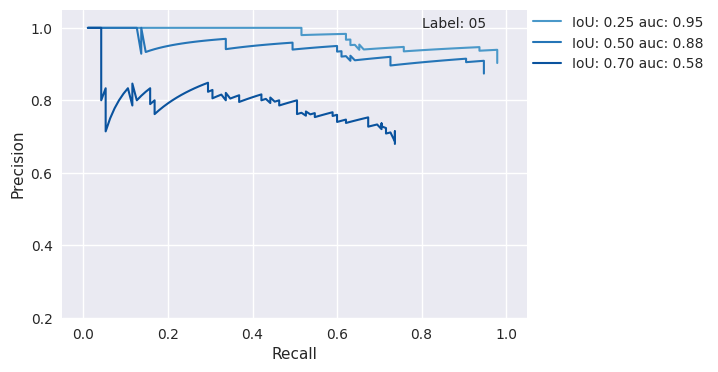

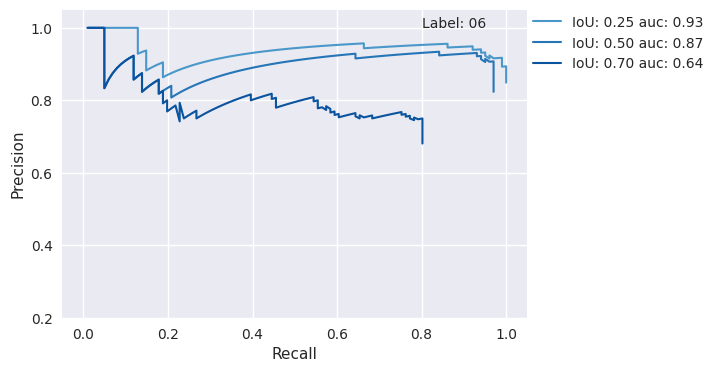

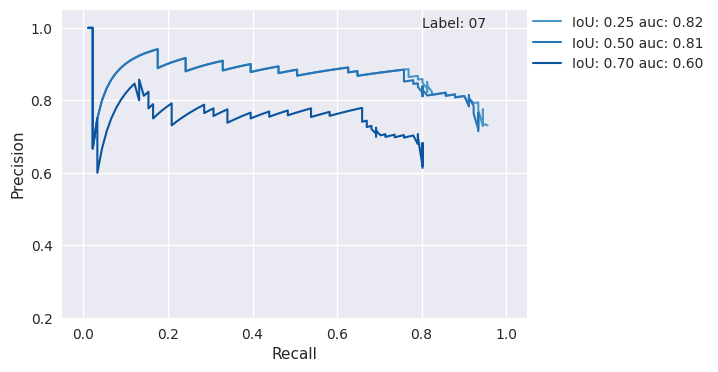

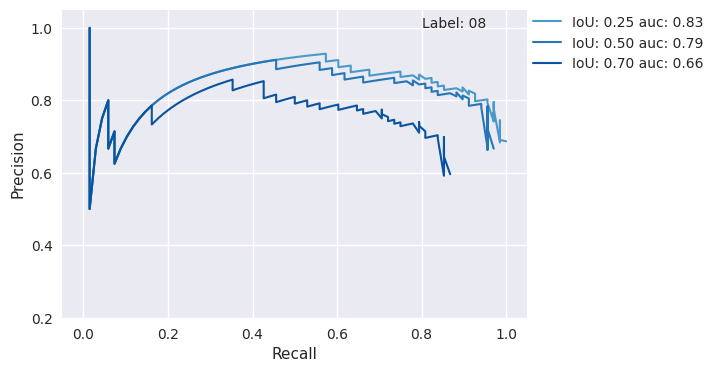

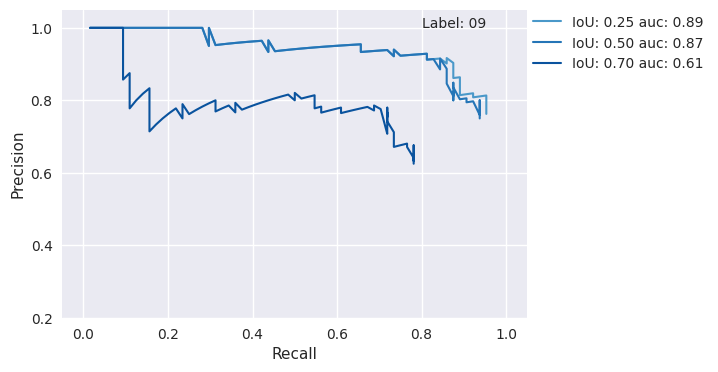

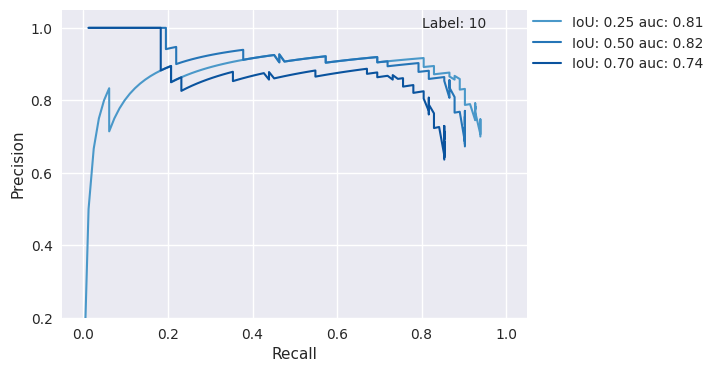

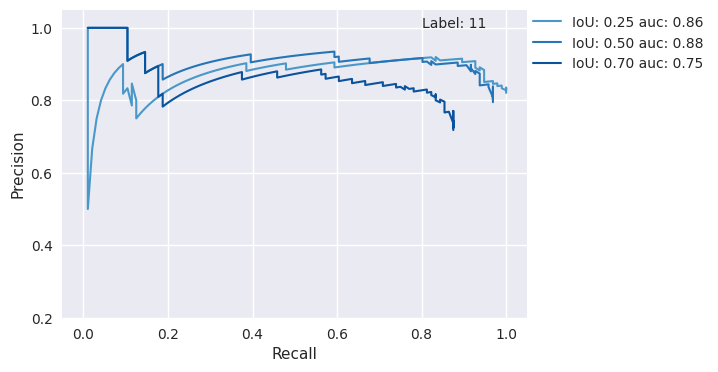

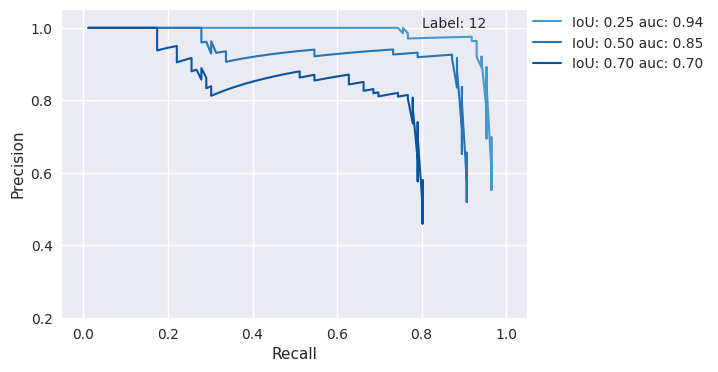

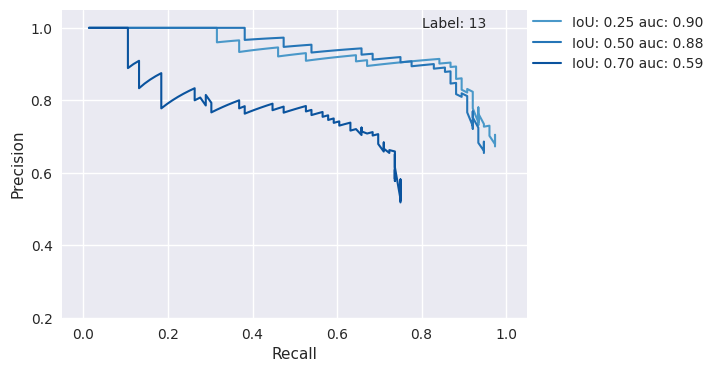

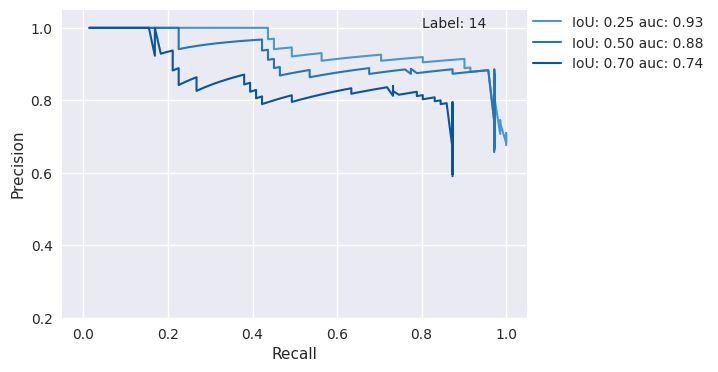

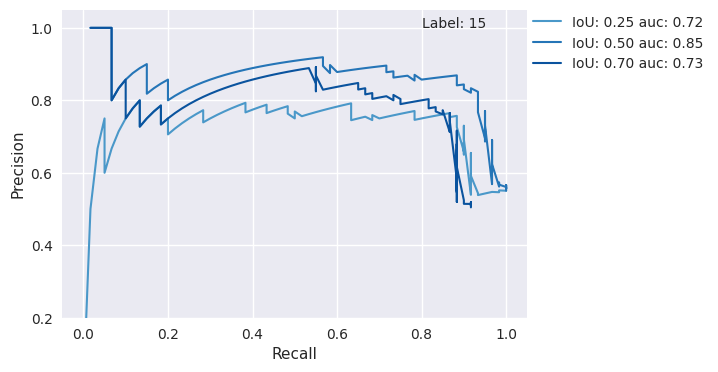

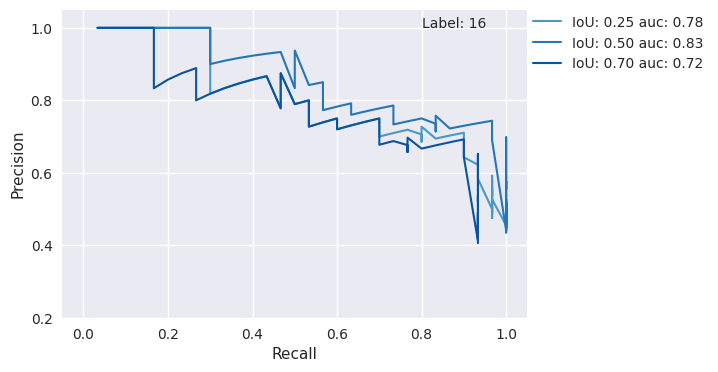

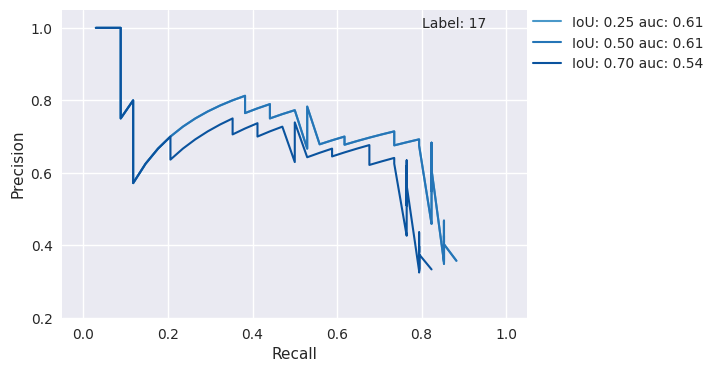

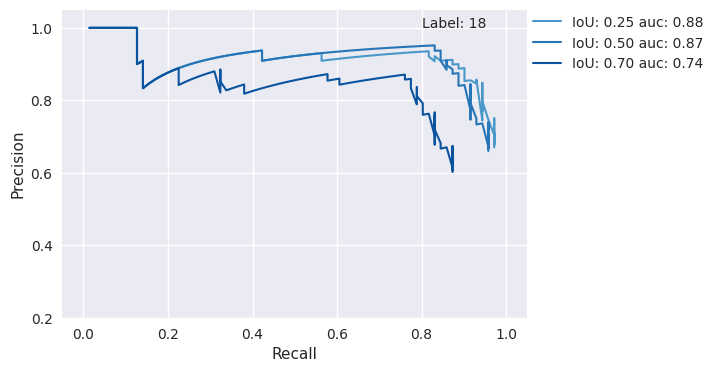

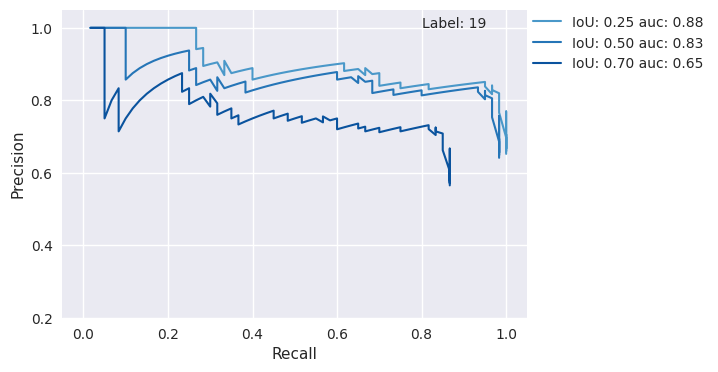

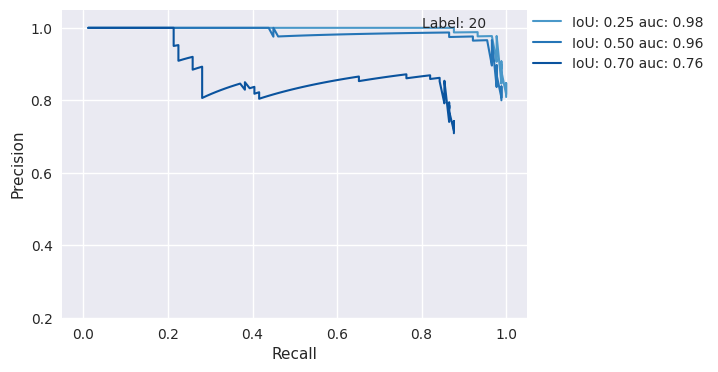

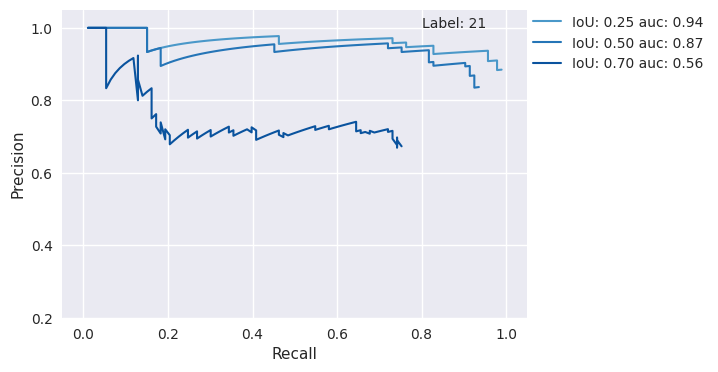

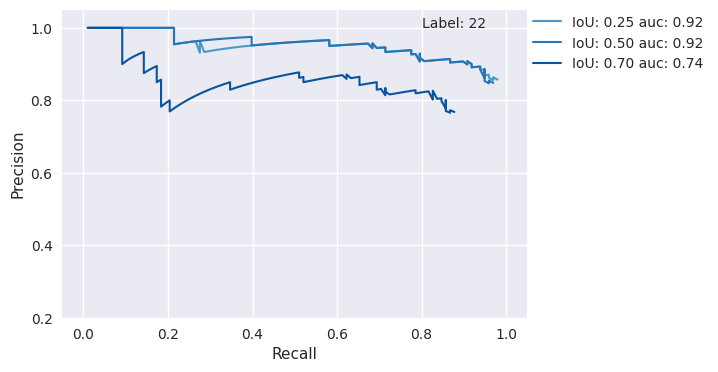

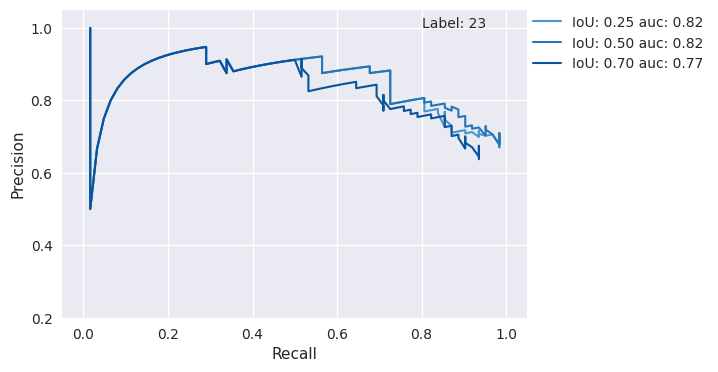

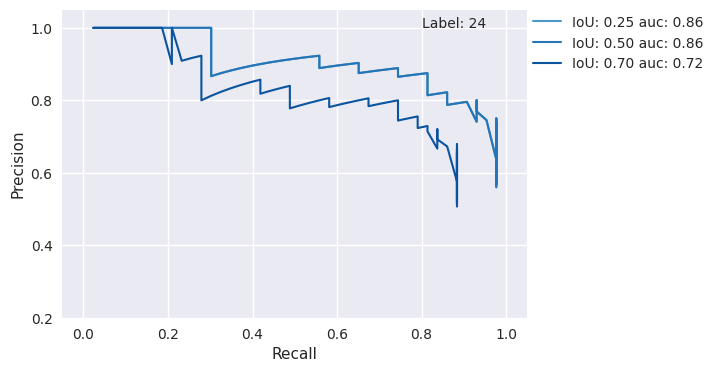

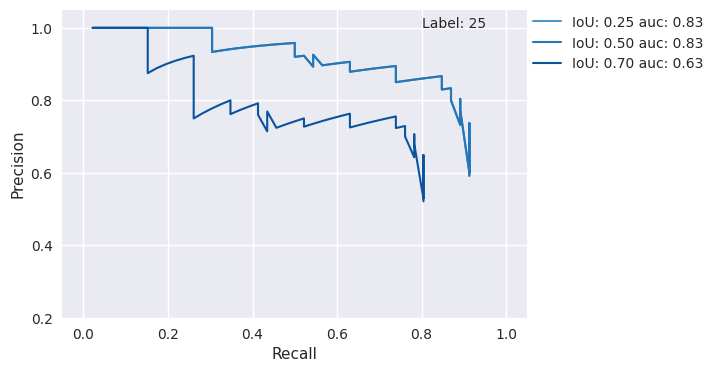

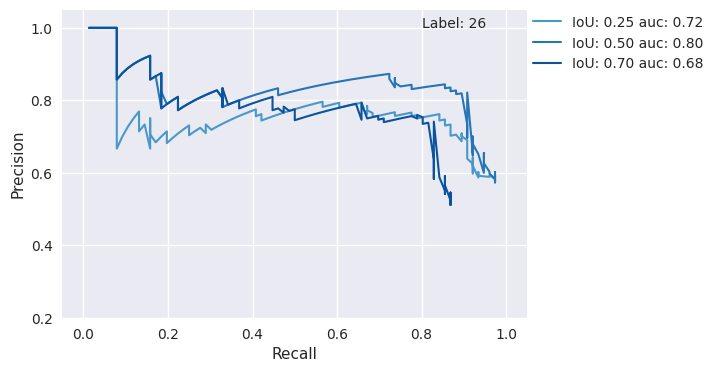

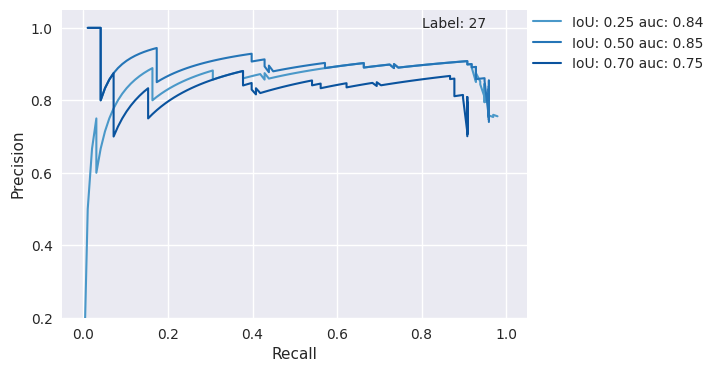

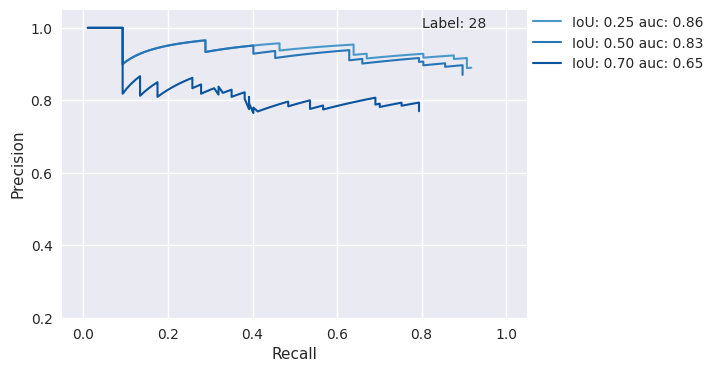

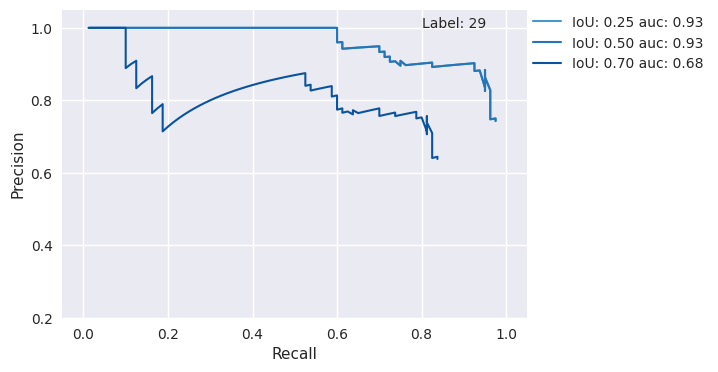

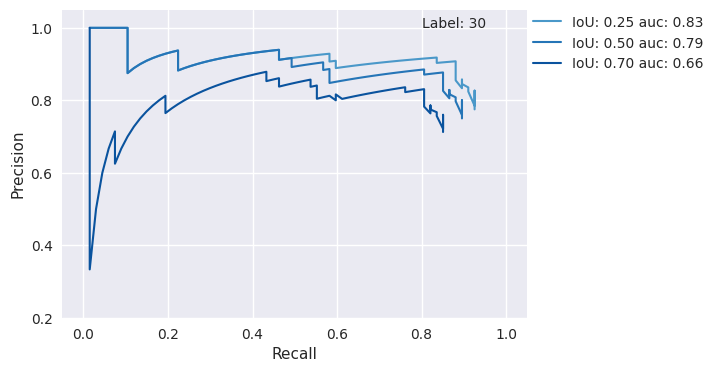

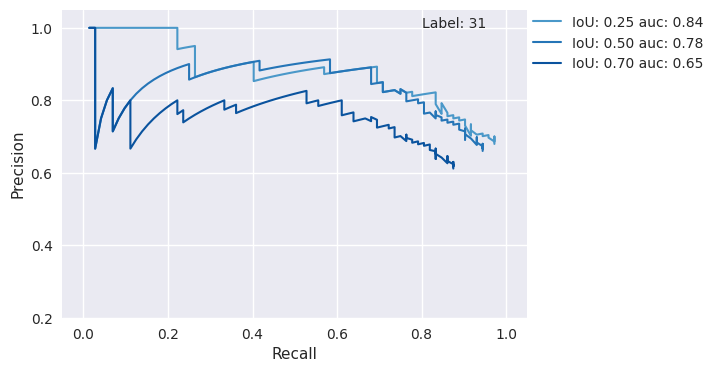

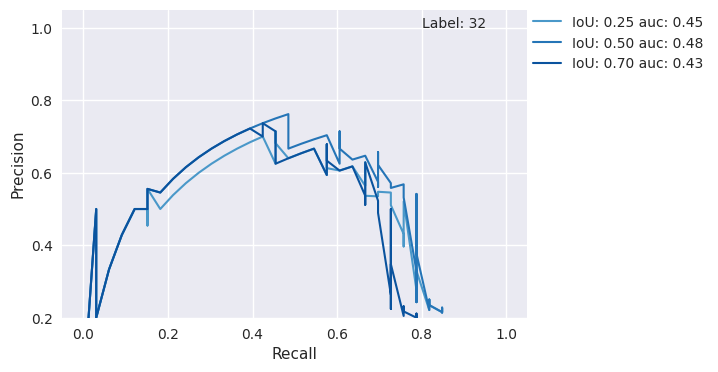

In [29]:
label_list = sorted(list(pr_df[label_col].unique()))

for label in label_list:

    # l = 10
    # label = label_list[l]
    
    fig_file_name = f'{model_name}_{str(label).zfill(2)}.png'
    fig_file = os.path.join(output_pr_dir, fig_file_name)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    
    for c, iou in enumerate(iou_list):
    
        pr_df_label = pr_df.loc[
                (pr_df[label_col] == label) & 
                (pr_df['iou_threshold'] == iou)].\
            sort_values(by='recall', ascending=True).\
            reset_index(drop=True)
        
        prec = pr_df_label['precision'].tolist()
        rec = pr_df_label['recall'].tolist()
        auc = skmetrics.auc(x=rec, y=prec)
        graph_label = f'IoU:{iou: .2f} auc:{auc: .2f}'
        
        ax.plot(rec, prec, linewidth=1.5, label=graph_label, color=colors[c])
        
        ax.set(xlim=[-0.05, 1.05], xticks=np.arange(0, 1.2, 0.2),
               ylim=[0.2, 1.05], yticks=np.arange(0.2, 1.2, 0.2),
               xlabel='Recall', ylabel='Precision')
    
        ax.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0.)
        
    ax.text(x=0.80, y=1.0, s=f'Label: {str(label).zfill(2)}', size=10)
    plt.savefig(fig_file, bbox_inches='tight')
    plt.show()